# Image Processing SoSe 2026 - Assignment - 06

### Deadline is 04.06.2026 at 11:55 a.m.

#### Students: Fabio Herrmann & Julius Böhm

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

In [1]:
# display the plots inside the notebook
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
import scipy.io.wavfile
from io import BytesIO
import urllib.request as urllib2
import IPython.display as adt
pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

# Exercise 1 - Cross-Correlation - 3 Points
Implement a function `my_cross_correlation`, which takes two discrete functions in the form of arrays as an input and outputs the resulting cross-correlation function. Now apply your correlation function as follows:
a) use as input function 1 an array of 10 random numbers (0-255), function 2 shall be `[1 2 3]`, plot the two functions and the result of the crosscorrelation of both.
b) use the same function 1 as in a), function 2 shall be `[2 2 2]`. Plot the two functions and the cross correlation of both.
c) repeat the first two tasks but swap the arguments

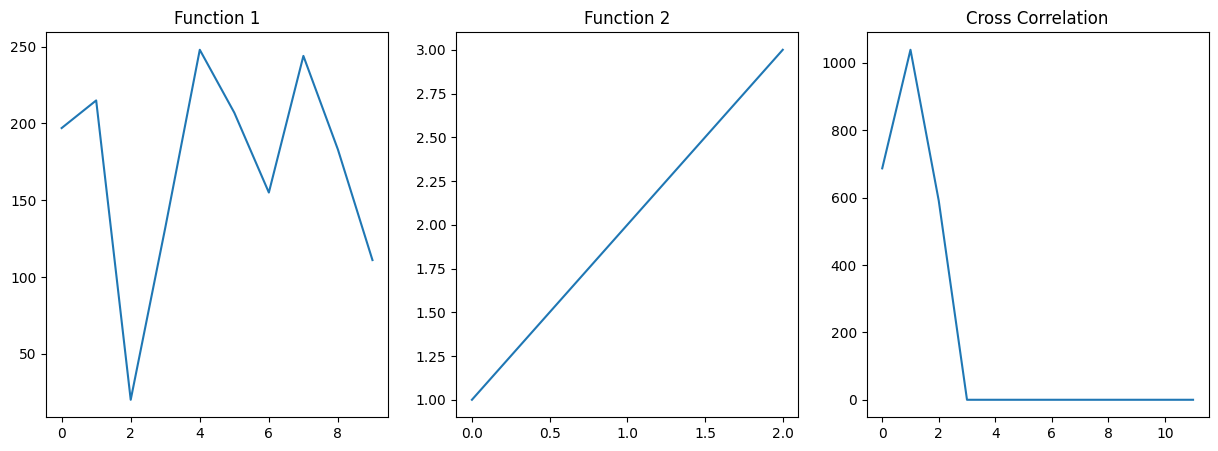

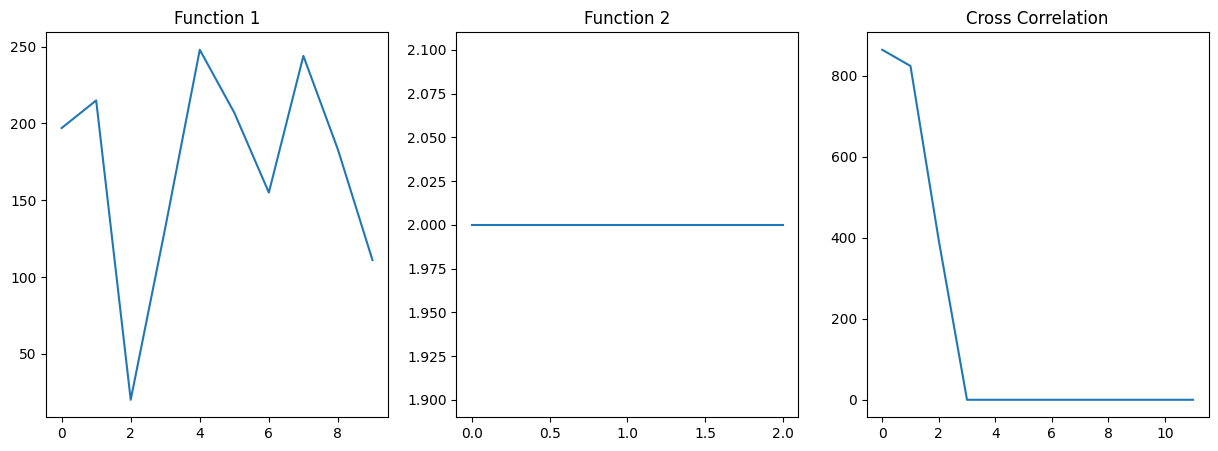

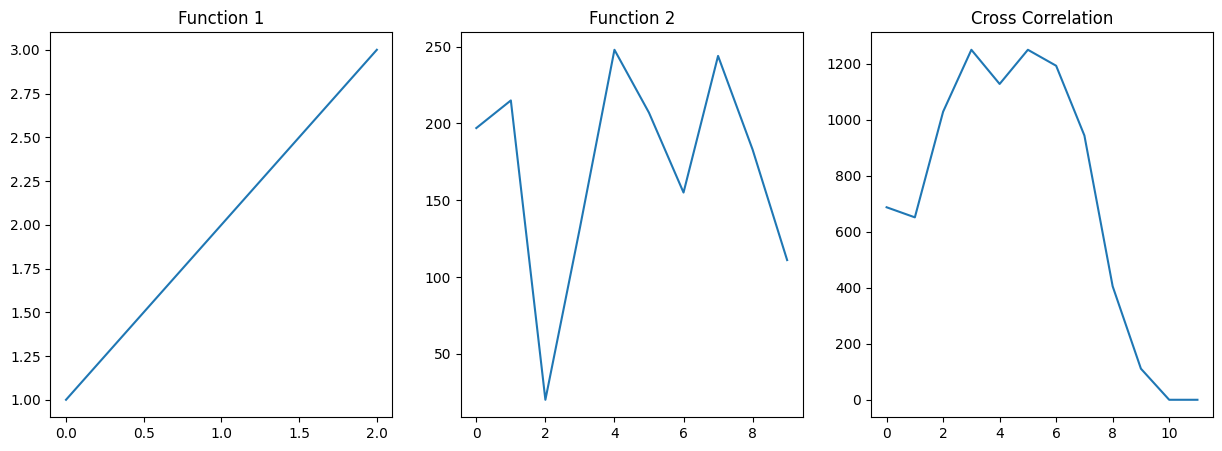

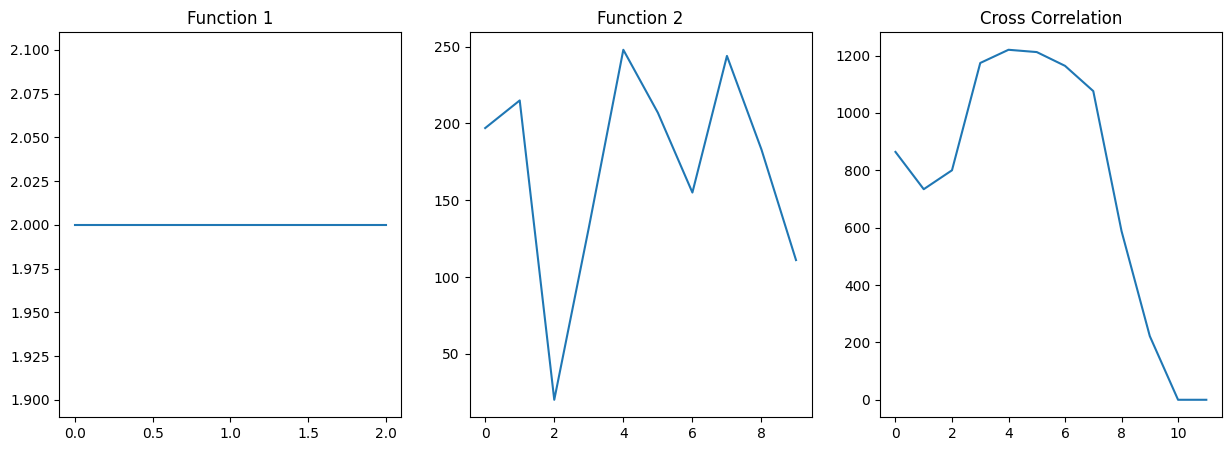

In [6]:
import random

def my_cross_correlation(func1, func2):
    L = len(func1) + len(func2) - 1
    fixed_func1 = [func1[i] if i < len(func1) else 0 for i in range(L)]
    fixed_func2 = [func2[i] if i < len(func2) else 0 for i in range(L)]
    correlation = []

    for i in range(L):
        s = 0
        for j in range(L):
            if 0 <= j + i < L:
                s += fixed_func1[j] * fixed_func2[j + i]
        correlation.append(s)

    return correlation

def plot_correlation(func1, func2):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(func1)
    ax[0].set_title('Function 1')
    ax[1].plot(func2)
    ax[1].set_title('Function 2')
    ax[2].plot(my_cross_correlation(func1, func2))
    ax[2].set_title('Cross Correlation')
    plt.show()


random.seed(0)
func0 = [random.randint(0, 255) for i in range(10)]
func1 = [1,2,3]
func2 = [2,2,2]

plot_correlation(func0, func1)
plot_correlation(func0, func2)
plot_correlation(func1, func0)
plot_correlation(func2, func0)

# Exercise 2 - DFT - 2 Points

Provide an orthogonal DFT matrix which can be used to transform one-dimensional signals of length 7. Calculate all elements (do not use variables) of the matrix.

<style>
/* wirkt in VS Code Markdown-Preview */
.math { text-align: left !important; }
.mjx-block { text-align: left !important; }
</style>

<div class="math">

$$
\frac{1}{\sqrt{7}} * 
\begin{bmatrix}
\omega^0_7 & \omega^0_7 & \omega^0_7    & \omega^0_7    & \omega^0_7    & \omega^0_7    & \omega^0_7    \\[4pt]
\omega^0_7 & \omega^1_7 & \omega^2_7    & \omega^3_7    & \omega^4_7    & \omega^5_7    & \omega^6_7    \\[4pt]
\omega^0_7 & \omega^2_7 & \omega^4_7    & \omega^6_7    & \omega^8_7    & \omega^{10}_7 & \omega^{12}_7 \\[4pt]
\omega^0_7 & \omega^3_7 & \omega^6_7    & \omega^9_7    & \omega^{12}_7 & \omega^{15}_7 & \omega^{18}_7 \\[4pt]
\omega^0_7 & \omega^4_7 & \omega^8_7    & \omega^{12}_7 & \omega^{16}_7 & \omega^{20}_7 & \omega^{24}_7 \\[4pt]
\omega^0_7 & \omega^5_7 & \omega^{10}_7 & \omega^{15}_7 & \omega^{20}_7 & \omega^{25}_7 & \omega^{30}_7 \\[4pt]
\omega^0_7 & \omega^6_7 & \omega^{12}_7 & \omega^{18}_7 & \omega^{24}_7 & \omega^{30}_7 & \omega^{36}_7 \\[4pt]
\end{bmatrix}
= 
\frac{1}{\sqrt{7}} * \begin{bmatrix}
\omega^0_7 & \omega^0_7 & \omega^0_7 & \omega^0_7 & \omega^0_7 & \omega^0_7 & \omega^0_7 \\[4pt]
\omega^0_7 & \omega^1_7 & \omega^2_7 & \omega^3_7 & \omega^4_7 & \omega^5_7 & \omega^6_7 \\[4pt]
\omega^0_7 & \omega^2_7 & \omega^4_7 & \omega^6_7 & \omega^1_7 & \omega^3_7 & \omega^5_7 \\[4pt]
\omega^0_7 & \omega^3_7 & \omega^6_7 & \omega^2_7 & \omega^5_7 & \omega^1_7 & \omega^4_7 \\[4pt]
\omega^0_7 & \omega^4_7 & \omega^1_7 & \omega^5_7 & \omega^2_7 & \omega^6_7 & \omega^3_7 \\[4pt]
\omega^0_7 & \omega^5_7 & \omega^3_7 & \omega^1_7 & \omega^6_7 & \omega^4_7 & \omega^2_7 \\[4pt]
\omega^0_7 & \omega^6_7 & \omega^5_7 & \omega^4_7 & \omega^3_7 & \omega^2_7 & \omega^1_7 \\[4pt]
\end{bmatrix}
= 
\frac{1}{\sqrt{7}} * \begin{bmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
1 & x & x & x & x & x & x \\[4pt]
\end{bmatrix}
$$

$$ mit \ \ \ \omega = e^{-2\pi i / N} = e^{2\pi i / 7} = cos(2\pi / 7) + i\ sin(2\pi / 7) $$


--------------------------

$$ mit \ \ \ \omega = e^{-2\pi i / N} \ \ \ , \ \ \ e^{ix} = cos(x) + i\ sin(x) \ \ \ und \ \ \ e^{i\pi} + 1 = 0 \ \ \ : $$

$$
\omega^0_7 = 1 \\
\omega^1_7 = e^{-2\pi i / 1} = cos(-2\pi / 7) + i\ sin(-2\pi / 7) = 0.6235 + 0,7818 i \\
\omega^2_7 = {e^{-2\pi i / 1}}^2 = {cos(-2\pi / 7) + i\ sin(-2\pi / 7)}^2 = 0,3888 + 0,4875 i - 0,6112 = -0,2224 + 0,4875 i \\
\omega^3_7 =  \\
\omega^4_7 =  \\
\omega^5_7 =  \\
\omega^6_7 =  \\
$$
</div>





-------------------------------------------------------------

$$\sqrt{a+b}$$

$$\sqrt[n]{x}$$

$$\frac{a+b}{c}$$

$$x^{2},\; y_{i}$$

$$\sum_{k=1}^{n} k,\; \int_{0}^{1} x\,dx$$

$$
\begin{pmatrix}
\sqrt{2} & \dfrac{1}{2} & 3\\[6pt]
\dfrac{\sqrt{a}}{b} & 5 & 6\\[6pt]
7 & 8 & \sqrt[3]{9}
\end{pmatrix}
$$

# Exercise 3 - Discrete Fourier Transformation - 2 Points
Implement the Discrete Fourier Transformation with [Matrix Multiplication](https://en.wikipedia.org/wiki/DFT_matrix).

In [ ]:
def dft_matrix(n):
    """
    Returns the Discrete Fourier Transformation Matrix of order `n`.
    """
    # your code here
    return np.zeros((n, n)) 

plt.subplot(121)
plt.imshow(dft_matrix(16))
plt.subplot(122)
plt.imshow(dft_matrix(32))
plt.show()

# Exercise 4 - Spectrogram - 3 Points

A [spectrogram](https://en.wikipedia.org/wiki/Spectrogram) visualises the intensities of the different frequencies over time. On the x-axis is the time and on the y-axis are the frequencies.
Your task is to build the spectrogram of the given audio clip. If you have not finished exercise 3, you can use a library for the fourier transformation.

In [ ]:
def load_wav(url):
    f = urllib2.urlopen(url)
    buffer = BytesIO(f.read())
    sample_rate, audio = scipy.io.wavfile.read(buffer)
    if len(audio.shape) == 2:
        # only select one channel
        audio = audio[:, 0]
    return sample_rate, audio / audio.max()

In [ ]:
dolphines_url = "http://www.pmel.noaa.gov/acoustics/whales/sounds/whalewav/akhumphi1x.wav"
# some dolphin sounds
sample_rate, audio = load_wav(dolphines_url)

In [ ]:
print(audio.shape)

In [ ]:
# listen to the audio, does not work when viewing in PyCharm
adt.Audio(data=audio, rate=sample_rate)

In [ ]:
# plot the values.
plt.plot(audio)
plt.show()

In [ ]:
def spectrogram(audio, window_size=500):
    """
    Builds the spectrogram of the audio clip. Split the audio clip into buckets of `window_size` and 
    use the discrete fourier transformation to get the intensity of the frequencies.
    The entry at position (i, j) of the matrix is the intensity of the i-th frequencies in the j-th bucket.
    """
    # your code here
    return np.zeros((window_size // 2, len(audio) // window_size))

In [ ]:
specgram = spectrogram(audio, window_size=500)

In [ ]:
im = plt.imshow(specgram)
plt.colorbar(im, fraction=0.02, pad=0.04)
plt.show()

In [ ]:
# plot it logarithmically
im = plt.imshow(specgram)
# your code here
plt.colorbar(im, fraction=0.02, pad=0.04)
plt.show()